Using device: cpu
[CHECK 1] df shape: (364997, 19)
[CHECK 1] Vocab sizes: {'Usage': 19, 'VehType': 16, 'VehPower': 9}

[CHECK 2] Numeric features (7): ['Expo', 'YearGap', 'CumClaimCount', 'ClaimRateSoFar', 'YearsSinceFirstClaimLog', 'PrevLabel', 'HasPriorClaim']


test: 100%|█████████████████████████████████████████████████████████████████████| 10709/10709 [00:12<00:00, 871.10it/s]



[CHECK 3] Sequences — train: 49,974, val: 10,709, test: 10,709
[CHECK 3] Test population size matches all other models (10,709) ✓

Model created. Total parameters: 88,833
Epoch  1/10 | train_loss: 0.9764 | val_loss: 0.9682
Epoch  2/10 | train_loss: 0.9636 | val_loss: 0.9587
Epoch  3/10 | train_loss: 0.9571 | val_loss: 0.9600
Epoch  4/10 | train_loss: 0.9553 | val_loss: 0.9613
Epoch  5/10 | train_loss: 0.9537 | val_loss: 0.9559
Epoch  6/10 | train_loss: 0.9527 | val_loss: 0.9562
Epoch  7/10 | train_loss: 0.9514 | val_loss: 0.9620
Epoch  8/10 | train_loss: 0.9521 | val_loss: 0.9537
Epoch  9/10 | train_loss: 0.9498 | val_loss: 0.9562
Epoch 10/10 | train_loss: 0.9505 | val_loss: 0.9558


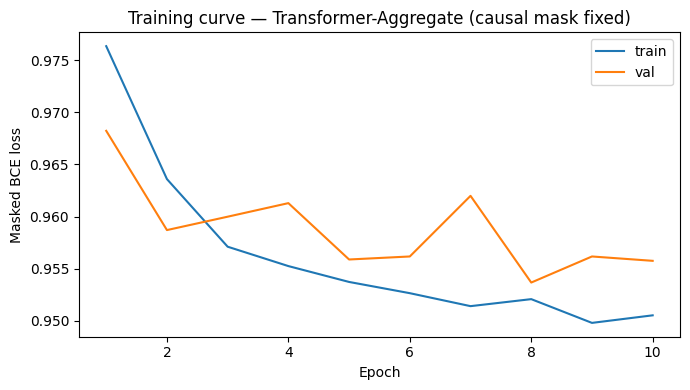


===== Test set evaluation (timestep-level) =====
Total timestep predictions: 54,755
AUC-ROC : 0.7914
F1-score: 0.3815

Best threshold : 0.661
Best F1-score  : 0.4085
  Precision    : 0.3228
  Recall       : 0.5562

Saved model and predictions.

===== Transformer-Aggregate (Model ④b, causal-mask fixed) Summary =====
Numeric features    : ['Expo', 'YearGap', 'CumClaimCount', 'ClaimRateSoFar', 'YearsSinceFirstClaimLog', 'PrevLabel', 'HasPriorClaim']
Causal mask          : ADDED (fix)
Total parameters     : 88,833
Test AUC-ROC         : 0.7914
Test F1-score(best)  : 0.4085


In [2]:
# ============================================================
# Notebook    : 04b_transformer_aggregate.ipynb (REVISED)
# Description : Case A extension — Model ④b Transformer-Aggregate,
#               RE-RUN with the causal mask fix (same as 03 and
#               04a's re-runs).
#
#               This is the critical re-check: the ORIGINAL run of
#               this notebook produced AUC 0.9922, which is almost
#               certainly look-ahead leakage — aggregate features
#               (CumClaimCount, ClaimRateSoFar, etc.) carry direct
#               information about future claims, and without a
#               causal mask, self-attention could read those future
#               values when predicting an earlier timestep. The
#               fixed version below should produce a much more
#               modest (and trustworthy) AUC, expected somewhere in
#               the neighborhood of 03c's LightGBM-Aggregate result
#               (0.7919), since both models now see the same
#               information at each timestep.
# ============================================================


# ============================================================
# 0. Install dependencies (run once)
# ============================================================
# pip install torch scikit-learn matplotlib tqdm


# ============================================================
# 1. Common imports
# ============================================================
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)


# ============================================================
# 2. Load aggregate data + existing split + existing vocabs
# ============================================================
df = pd.read_csv("data/fremotor_multi_history_aggregate.csv")

with open("data/sequences/split_idpols.json", "r", encoding="utf-8") as f:
    split_ids = json.load(f)
with open("data/sequences/vocabs.json", "r", encoding="utf-8") as f:
    vocabs = json.load(f)

vocab_sizes = {k: len(v) for k, v in vocabs.items()}
CAT_COLS = list(vocabs.keys())

for col in CAT_COLS:
    df[col + "_idx"] = df[col].map(vocabs[col])

print(f"[CHECK 1] df shape: {df.shape}")
print(f"[CHECK 1] Vocab sizes: {vocab_sizes}")


# ============================================================
# 3. Feature scope — UNCHANGED from original 04b
# ============================================================
NUMERIC_COLS = [
    "Expo", "YearGap",
    "CumClaimCount", "ClaimRateSoFar", "YearsSinceFirstClaimLog",
    "PrevLabel", "HasPriorClaim",
]
LABEL_COL = "Label"

print(f"\n[CHECK 2] Numeric features ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")


# ============================================================
# 4. Build sequences — UNCHANGED
# ============================================================
train_idpols = set(split_ids["train"])
val_idpols   = set(split_ids["val"])
test_idpols  = set(split_ids["test"])

df_sorted = df.sort_values(["IDpol", "Year"])
grouped_data = {k: v for k, v in df_sorted.groupby("IDpol")}

CAT_IDX_COLS = [c + "_idx" for c in CAT_COLS]

def build_sequences(ids, grouped_dict, desc="building"):
    sequences = []
    for idpol in tqdm(ids, desc=desc):
        sub = grouped_dict[idpol]
        seq = {
            "IDpol"    : idpol,
            "length"   : len(sub),
            "numeric"  : sub[NUMERIC_COLS].values.astype(np.float32),
            "cat_idx"  : sub[CAT_IDX_COLS].values.astype(np.int64),
            "label"    : sub[LABEL_COL].values.astype(np.int64),
        }
        sequences.append(seq)
    return sequences

train_seqs = build_sequences(list(train_idpols), grouped_data, desc="train")
val_seqs   = build_sequences(list(val_idpols),   grouped_data, desc="val")
test_seqs  = build_sequences(list(test_idpols),  grouped_data, desc="test")

print(f"\n[CHECK 3] Sequences — train: {len(train_seqs):,}, "
      f"val: {len(val_seqs):,}, test: {len(test_seqs):,}")

assert len(test_seqs) == 10709, \
    f"Test population mismatch! Expected 10,709 IDpols, got {len(test_seqs)}"
print(f"[CHECK 3] Test population size matches all other models (10,709) ✓")


# ============================================================
# 5. Dataset / collate — UNCHANGED
# ============================================================
class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_fn(batch):
    max_len = max(item["length"] for item in batch)
    batch_size = len(batch)
    n_numeric = batch[0]["numeric"].shape[1]
    n_cat     = batch[0]["cat_idx"].shape[1]

    numeric_padded = torch.zeros(batch_size, max_len, n_numeric, dtype=torch.float32)
    cat_idx_padded = torch.zeros(batch_size, max_len, n_cat, dtype=torch.long)
    label_padded   = torch.zeros(batch_size, max_len, dtype=torch.float32)
    attention_mask = torch.zeros(batch_size, max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]
        numeric_padded[i, :L] = torch.tensor(item["numeric"])
        cat_idx_padded[i, :L] = torch.tensor(item["cat_idx"])
        label_padded[i, :L]   = torch.tensor(item["label"], dtype=torch.float32)
        attention_mask[i, :L] = True

    return {
        "numeric": numeric_padded,
        "cat_idx": cat_idx_padded,
        "label":   label_padded,
        "mask":    attention_mask,
    }

BATCH_SIZE = 32
train_loader = DataLoader(SequenceDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(SequenceDataset(val_seqs),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(SequenceDataset(test_seqs),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


# ============================================================
# 6. Model definition — CAUSAL MASK ADDED (the critical fix),
#    dtype-aligned same as 04a's re-run
# ============================================================
class TimestepRiskTransformer(nn.Module):
    def __init__(self, vocab_sizes, n_numeric, emb_dim=64, n_heads=4,
                 n_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()
        cat_cols = list(vocab_sizes.keys())
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(vocab_sizes[col], emb_dim, padding_idx=0)
            for col in cat_cols
        })
        self.numeric_proj = nn.Linear(n_numeric, emb_dim)
        combined_dim = emb_dim * (len(cat_cols) + 1)
        self.input_proj = nn.Linear(combined_dim, emb_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, 1),
        )

    def forward(self, numeric, cat_idx, attention_mask):
        cat_embeds = []
        for i, col in enumerate(self.cat_cols):
            cat_embeds.append(self.embeddings[col](cat_idx[:, :, i]))
        cat_embeds = torch.cat(cat_embeds, dim=-1)
        num_embed = self.numeric_proj(numeric)
        combined = torch.cat([cat_embeds, num_embed], dim=-1)
        x = self.input_proj(combined)

        # CAUSAL MASK — the critical fix for this notebook
        T = x.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        padding_mask_float = torch.zeros_like(attention_mask, dtype=torch.float32)
        padding_mask_float.masked_fill_(~attention_mask, float("-inf"))

        encoded = self.encoder(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask_float,
        )

        logits = self.classifier(encoded).squeeze(-1)
        return logits


N_NUMERIC = len(NUMERIC_COLS)  # 7
model = TimestepRiskTransformer(vocab_sizes=vocab_sizes, n_numeric=N_NUMERIC).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel created. Total parameters: {n_params:,}")


# ============================================================
# 7. Loss — UNCHANGED
# ============================================================
POS_WEIGHT = torch.tensor((1 - 0.1267) / 0.1267)
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT, reduction="none")

def masked_bce_loss(logits, labels, mask):
    loss = criterion(logits, labels)
    loss = loss * mask.float()
    return loss.sum() / mask.float().sum()


# ============================================================
# 8. Training loop — UNCHANGED
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
N_EPOCHS = 10
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_train_loss, n_batches = 0.0, 0
    for batch in train_loader:
        numeric = batch["numeric"].to(DEVICE)
        cat_idx = batch["cat_idx"].to(DEVICE)
        label   = batch["label"].to(DEVICE)
        mask    = batch["mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(numeric, cat_idx, mask)
        loss = masked_bce_loss(logits, label, mask)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss, n_val_batches = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            numeric = batch["numeric"].to(DEVICE)
            cat_idx = batch["cat_idx"].to(DEVICE)
            label   = batch["label"].to(DEVICE)
            mask    = batch["mask"].to(DEVICE)
            logits = model(numeric, cat_idx, mask)
            loss = masked_bce_loss(logits, label, mask)
            epoch_val_loss += loss.item()
            n_val_batches += 1

    avg_val_loss = epoch_val_loss / n_val_batches
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch:2d}/{N_EPOCHS} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")


# ============================================================
# 9. Plot
# ============================================================
plt.figure(figsize=(7, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, N_EPOCHS + 1), val_losses, label="val")
plt.xlabel("Epoch"); plt.ylabel("Masked BCE loss")
plt.title("Training curve — Transformer-Aggregate (causal mask fixed)")
plt.legend(); plt.tight_layout()
plt.savefig("data/sequences/training_curve_aggregate_fixed.png")
plt.show()


# ============================================================
# 10. Evaluation — UNCHANGED convention
# ============================================================
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        numeric = batch["numeric"].to(DEVICE)
        cat_idx = batch["cat_idx"].to(DEVICE)
        label   = batch["label"].to(DEVICE)
        mask    = batch["mask"].to(DEVICE)
        logits = model(numeric, cat_idx, mask)
        all_logits.append(logits[mask].numpy())
        all_labels.append(label[mask].numpy())

all_logits = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels)
all_probs  = 1 / (1 + np.exp(-all_logits))

auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, (all_probs >= 0.5).astype(int))

print("\n===== Test set evaluation (timestep-level) =====")
print(f"Total timestep predictions: {len(all_labels):,}")
print(f"AUC-ROC : {auc:.4f}")
print(f"F1-score: {f1:.4f}")

precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
print(f"\nBest threshold : {thresholds[best_idx]:.3f}")
print(f"Best F1-score  : {f1_scores[best_idx]:.4f}")
print(f"  Precision    : {precisions[best_idx]:.4f}")
print(f"  Recall       : {recalls[best_idx]:.4f}")


# ============================================================
# 11. Save (NEW filenames — fixed version)
# ============================================================
torch.save(model.state_dict(), "data/sequences/transformer_aggregate_model_fixed.pt")
np.savez(
    "data/sequences/transformer_aggregate_test_predictions_fixed.npz",
    logits=all_logits, labels=all_labels, probs=all_probs,
)
print("\nSaved model and predictions.")


# ============================================================
# 12. Summary
# ============================================================
print("\n===== Transformer-Aggregate (Model ④b, causal-mask fixed) Summary =====")
print(f"Numeric features    : {NUMERIC_COLS}")
print(f"Causal mask          : ADDED (fix)")
print(f"Total parameters     : {n_params:,}")
print(f"Test AUC-ROC         : {auc:.4f}")
print(f"Test F1-score(best)  : {f1_scores[best_idx]:.4f}")
print("======================================")

In [4]:
# ============================================================
# Cleanup script — remove buggy (pre-causal-mask) Transformer
# artifacts, rename "_fixed" files to the canonical names, and
# print a final manifest of what belongs to which model (①-④b).
#
# Run with DRY_RUN=True first to see what would happen, then
# set DRY_RUN=False to actually execute.
# ============================================================

import os
import shutil

DRY_RUN = False  # <-- set to False after reviewing the printed plan

SEQ_DIR = "data/sequences"

# ------------------------------------------------------------
# Step 1: files to DELETE (buggy pre-fix runs, causal mask missing)
# ------------------------------------------------------------
files_to_delete = [
    "transformer_model.pt",                          # ④ original (buggy, but AUC was fine by luck)
    "test_predictions.npz",                           # ④ original predictions
    "transformer_static_model.pt",                    # ③ original (buggy)
    "transformer_static_test_predictions.npz",
    "transformer_aggregate_model.pt",                 # ④b original (SEVERELY buggy — AUC 0.99)
    "transformer_aggregate_test_predictions.npz",
    "training_curve.png",                              # ④ original training curve
    "training_curve_static.png",                       # ③ original training curve
    "training_curve_aggregate.png",                    # ④b original training curve
]

# ------------------------------------------------------------
# Step 2: files to RENAME (drop "_fixed" suffix -> becomes canonical)
# ------------------------------------------------------------
files_to_rename = {
    "transformer_longitudinal_model_fixed.pt":              "transformer_longitudinal_model.pt",
    "transformer_longitudinal_test_predictions_fixed.npz":  "transformer_longitudinal_test_predictions.npz",
    "transformer_static_model_fixed.pt":                    "transformer_static_model.pt",
    "transformer_static_test_predictions_fixed.npz":        "transformer_static_test_predictions.npz",
    "transformer_aggregate_model_fixed.pt":                 "transformer_aggregate_model.pt",
    "transformer_aggregate_test_predictions_fixed.npz":     "transformer_aggregate_test_predictions.npz",
    "training_curve_longitudinal_fixed.png":                "training_curve_longitudinal.png",
    "training_curve_static_fixed.png":                      "training_curve_static.png",
    "training_curve_aggregate_fixed.png":                   "training_curve_aggregate.png",
}

# ------------------------------------------------------------
# Step 3: files that were NEVER buggy (LightGBM, unaffected by
# the causal-mask issue) — listed here only for the manifest,
# not touched
# ------------------------------------------------------------
files_unaffected = [
    "lightgbm_static_model.txt",
    "lightgbm_static_test_predictions.npz",
    "lightgbm_longitudinal_model.txt",
    "lightgbm_longitudinal_test_predictions.npz",
    "lightgbm_aggregate_model.txt",
    "lightgbm_aggregate_test_predictions.npz",
]

print(f"{'='*60}")
print(f"DRY_RUN = {DRY_RUN}")
print(f"{'='*60}")

print(f"\n[1] Files to DELETE ({len(files_to_delete)}):")
for fname in files_to_delete:
    fpath = os.path.join(SEQ_DIR, fname)
    exists = os.path.exists(fpath)
    print(f"  {'[EXISTS]' if exists else '[missing]'} {fpath}")
    if exists and not DRY_RUN:
        os.remove(fpath)
        print(f"    -> deleted")

print(f"\n[2] Files to RENAME ({len(files_to_rename)}):")
for old_name, new_name in files_to_rename.items():
    old_path = os.path.join(SEQ_DIR, old_name)
    new_path = os.path.join(SEQ_DIR, new_name)
    exists = os.path.exists(old_path)
    print(f"  {'[EXISTS]' if exists else '[missing]'} {old_path}")
    print(f"    -> {new_path}")
    if exists and not DRY_RUN:
        shutil.move(old_path, new_path)
        print(f"    -> renamed")

print(f"\n[3] Files UNAFFECTED by the bug (left as-is):")
for fname in files_unaffected:
    fpath = os.path.join(SEQ_DIR, fname)
    exists = os.path.exists(fpath)
    print(f"  {'[EXISTS]' if exists else '[missing]'} {fpath}")

if DRY_RUN:
    print(f"\n{'='*60}")
    print("DRY RUN COMPLETE — nothing was actually deleted or renamed.")
    print("Review the plan above, then set DRY_RUN=False and re-run.")
    print(f"{'='*60}")
else:
    print(f"\n{'='*60}")
    print("CLEANUP COMPLETE.")
    print(f"{'='*60}")


# ============================================================
# Final manifest — canonical filename <-> model identity
# ============================================================
print("\n\n===== FINAL MODEL MANIFEST (①-④b) =====\n")

manifest = [
    ("①",  "LightGBM-Static",        "lightgbm_static_model.txt",        "lightgbm_static_test_predictions.npz",        0.7686),
    ("②",  "LightGBM-Longitudinal",  "lightgbm_longitudinal_model.txt",  "lightgbm_longitudinal_test_predictions.npz",  0.7689),
    ("③c", "LightGBM-Aggregate",     "lightgbm_aggregate_model.txt",     "lightgbm_aggregate_test_predictions.npz",     0.7919),
    ("③",  "Transformer-Static",     "transformer_static_model.pt",      "transformer_static_test_predictions.npz",     0.7664),
    ("④",  "Transformer-Longitudinal","transformer_longitudinal_model.pt","transformer_longitudinal_test_predictions.npz",0.7669),
    ("④b", "Transformer-Aggregate",  "transformer_aggregate_model.pt",   "transformer_aggregate_test_predictions.npz",  0.7914),
]

print(f"{'ID':4s} {'Model':26s} {'AUC':8s} {'Model file':38s} {'Predictions file'}")
print("-" * 130)
for mid, name, model_file, pred_file, auc in manifest:
    print(f"{mid:4s} {name:26s} {auc:<8.4f} {model_file:38s} {pred_file}")

print(f"\nAll Transformer results above (③④④b) are POST causal-mask-fix.")
print(f"All LightGBM results (①②③c) were never affected by the bug.")
print(f"Data source of truth: data/fremotor_multi_history_features.csv (①②③④),")
print(f"                       data/fremotor_multi_history_aggregate.csv (③c④b)")

DRY_RUN = False

[1] Files to DELETE (9):
  [missing] data/sequences\transformer_model.pt
  [missing] data/sequences\test_predictions.npz
  [EXISTS] data/sequences\transformer_static_model.pt
    -> deleted
  [EXISTS] data/sequences\transformer_static_test_predictions.npz
    -> deleted
  [EXISTS] data/sequences\transformer_aggregate_model.pt
    -> deleted
  [EXISTS] data/sequences\transformer_aggregate_test_predictions.npz
    -> deleted
  [missing] data/sequences\training_curve.png
  [EXISTS] data/sequences\training_curve_static.png
    -> deleted
  [EXISTS] data/sequences\training_curve_aggregate.png
    -> deleted

[2] Files to RENAME (9):
  [EXISTS] data/sequences\transformer_longitudinal_model_fixed.pt
    -> data/sequences\transformer_longitudinal_model.pt
    -> renamed
  [EXISTS] data/sequences\transformer_longitudinal_test_predictions_fixed.npz
    -> data/sequences\transformer_longitudinal_test_predictions.npz
    -> renamed
  [EXISTS] data/sequences\transformer_static_mode